<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Lesson13_Optuna%26Clustering/How_HDBSCAN_Works.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HDBSCAN

* https://towardsdatascience.com/a-gentle-introduction-to-hdbscan-and-density-based-clustering-5fd79329c1e8

* https://pberba.github.io/stats/2020/01/17/hdbscan/

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets as data
%matplotlib inline
sns.set_context('poster')
sns.set_style('white')
sns.set_color_codes()
plot_kwds = {'alpha' : 0.5, 's' : 80, 'linewidths':0}

Сгенерируем данные

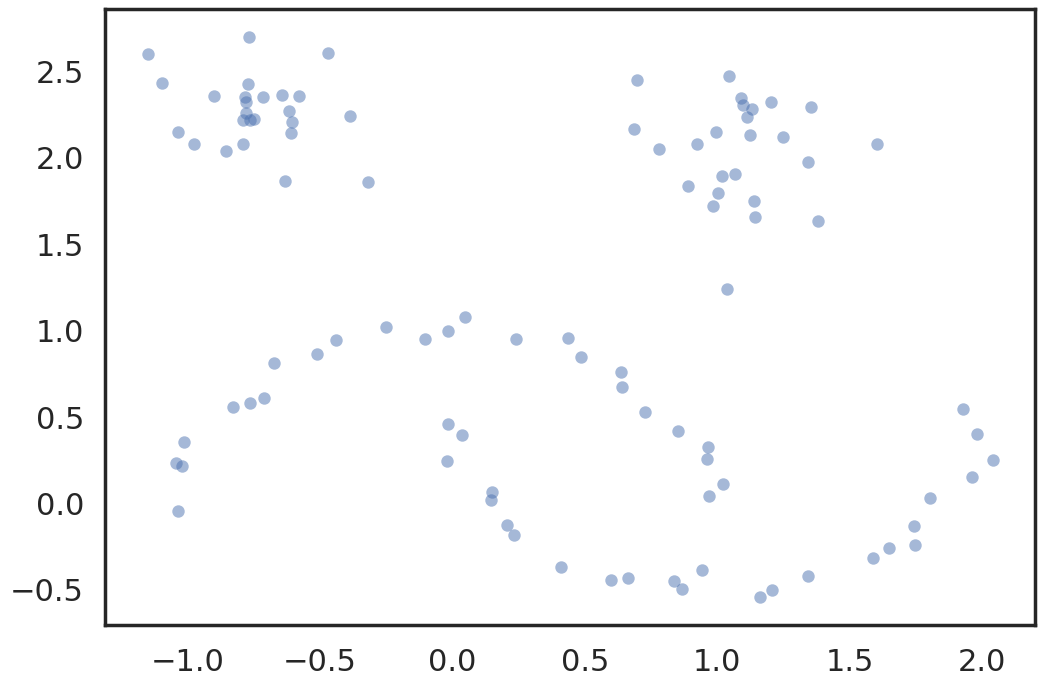

In [ ]:
plt.figure(figsize=(12,8))

moons, _ = data.make_moons(n_samples=50, noise=0.05)
blobs, _ = data.make_blobs(n_samples=50, centers=[(-0.75,2.25), (1.0, 2.0)], cluster_std=0.25)
test_data = np.vstack([moons, blobs])
plt.scatter(test_data.T[0], test_data.T[1], color='b', **plot_kwds)

Установим библиотеку

In [ ]:
!pip install hdbscan

In [ ]:
import hdbscan

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [ ]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=5, gen_min_span_tree=True)
clusterer.fit(test_data)

HDBSCAN(gen_min_span_tree=True)

Алгоритм вкратце

1. Аппроксимируем распределение данных с помощью расстояния до k-го соседа
2. Строим минимальное остовное дерево
3. Строим иерархию кластеров
4. Схлопываем кластеры по параметру min_cluster_size
5. Извлекаем итоговые кластеры

Аппроксимируем плотность распределения данных расстоянием до k-го соседа.

Затем строим минимальное остовное дерево.

Здесь мы соединяем ребрами достижимые точки, причем чем жирнее ребро, тем при большем лямбда (в области большей плотности) точки достижимы, и наоборот.

<Axes: >

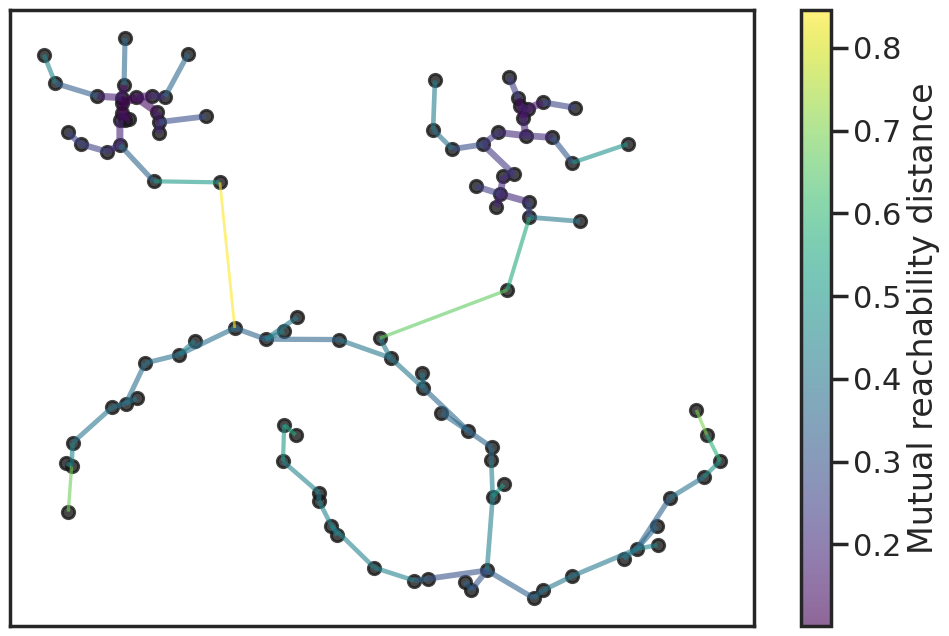

In [ ]:
plt.figure(figsize=(12,8))

clusterer.minimum_spanning_tree_.plot(edge_cmap='viridis',
                                      edge_alpha=0.6,
                                      node_size=80,
                                      edge_linewidth=2)

## Иерархия кластеров

<Axes: ylabel='distance'>

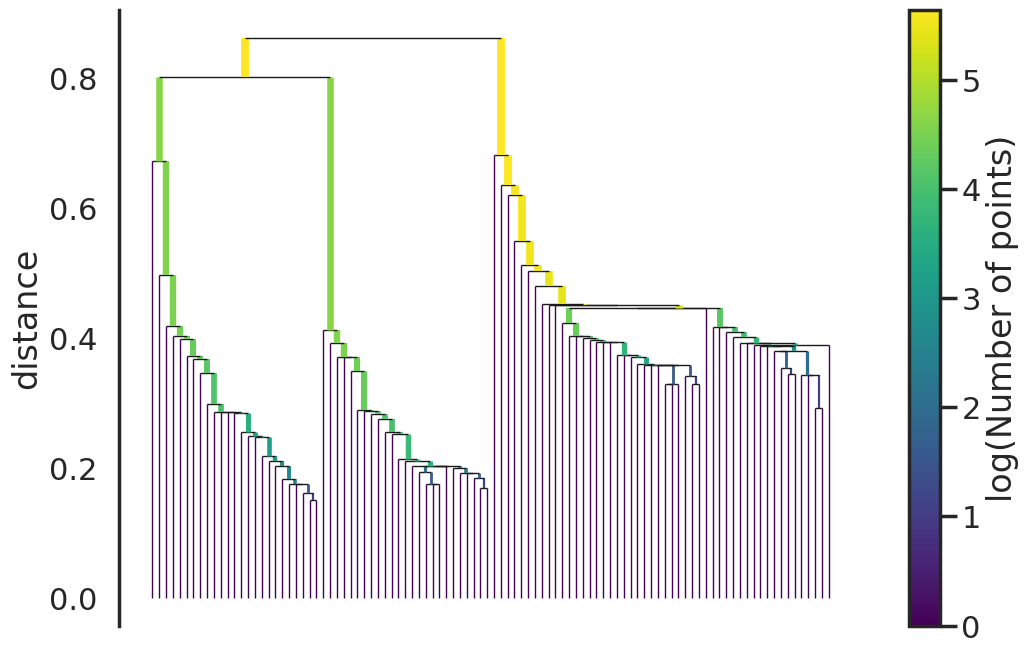

In [ ]:
plt.figure(figsize=(12,8))

clusterer.single_linkage_tree_.plot(cmap='viridis', colorbar=True)

DBSCAN выберет кластеры по фиксированному порогу distance. HDBSCAN идет чуть дальше.

## Схлопываем кластеры

<Axes: ylabel='$\\lambda$ value'>

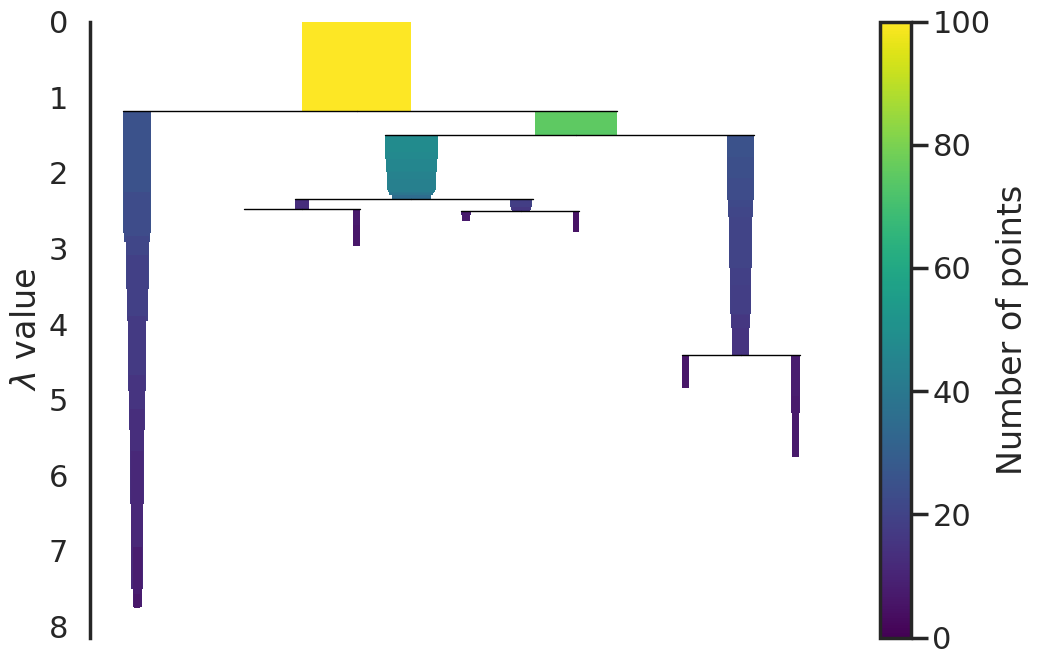

In [ ]:
plt.figure(figsize=(12,8))

clusterer.condensed_tree_.plot()

## Извлекаем итоговые кластеры

<Axes: ylabel='$\\lambda$ value'>

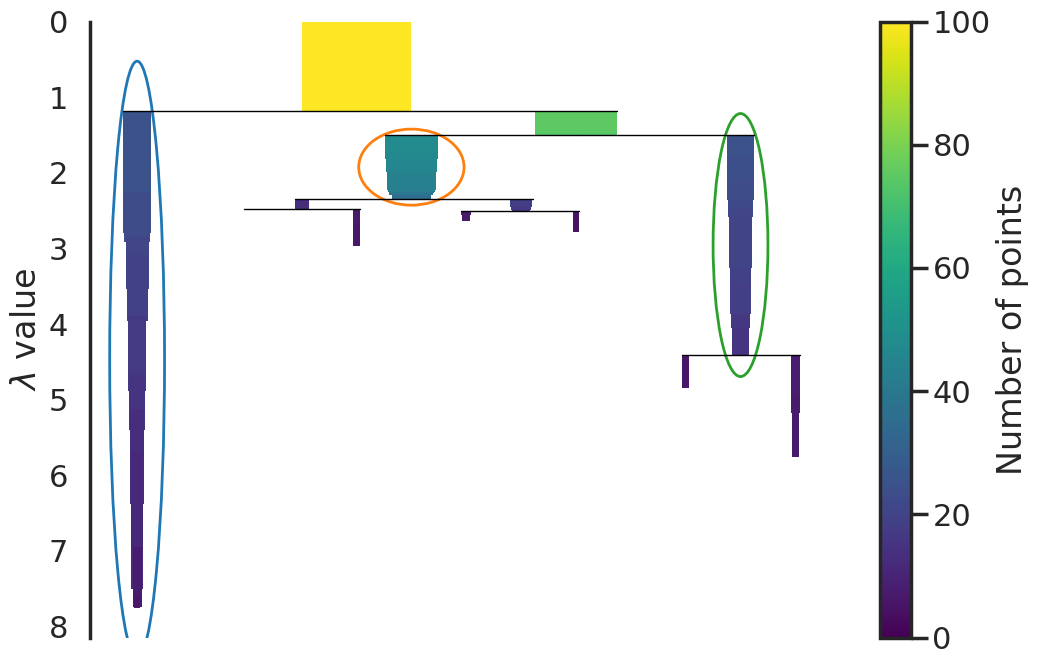

In [ ]:
plt.figure(figsize=(12,8))

clusterer.condensed_tree_.plot(select_clusters=True, selection_palette=sns.color_palette())

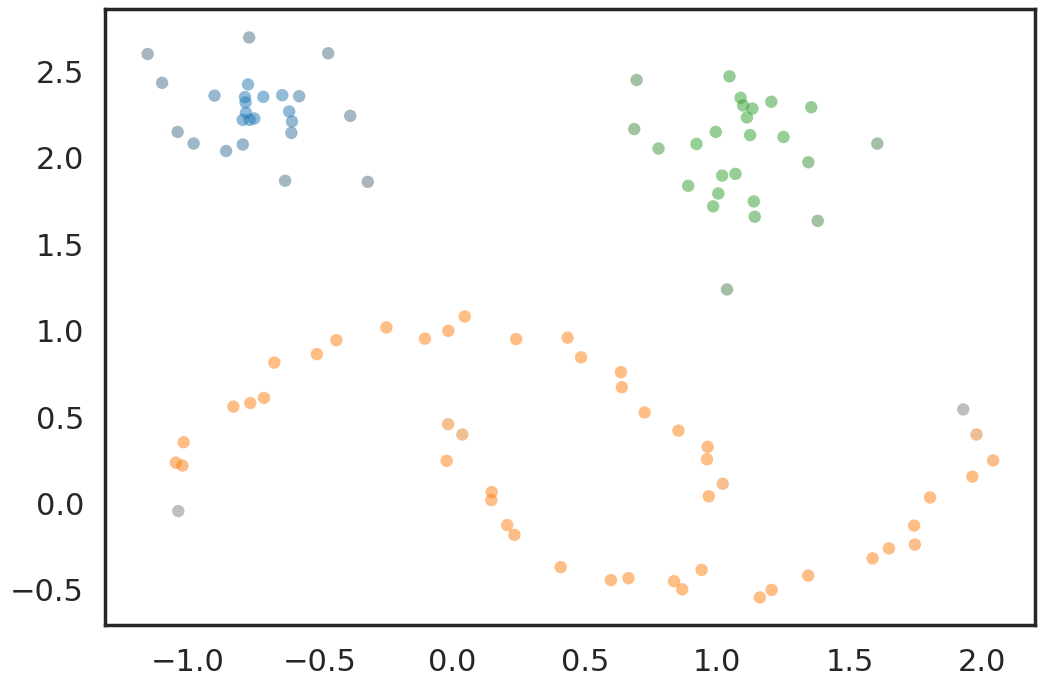

In [ ]:
plt.figure(figsize=(12,8))

palette = sns.color_palette()
cluster_colors = [sns.desaturate(palette[col], sat)
                  if col >= 0 else (0.5, 0.5, 0.5) for col, sat in
                  zip(clusterer.labels_, clusterer.probabilities_)]
plt.scatter(test_data.T[0], test_data.T[1], c=cluster_colors, **plot_kwds)

# Сравнение с DBSCAN

In [ ]:
test_data = np.load('clusterable_data.npy')

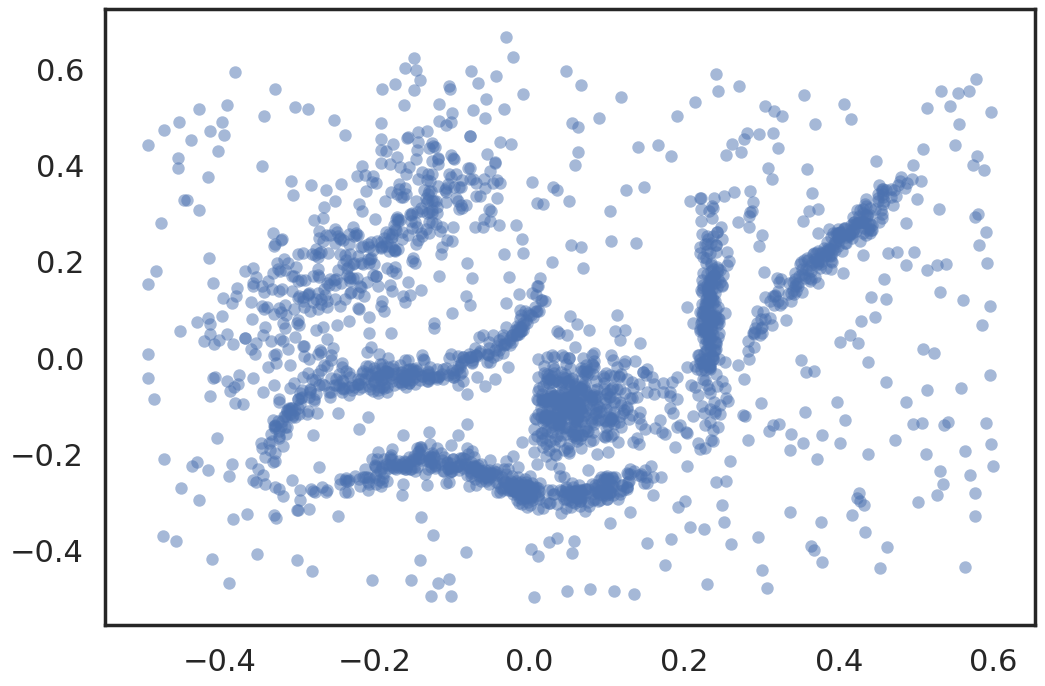

In [ ]:
plt.figure(figsize=(12,8))

plt.scatter(test_data.T[0], test_data.T[1], color='b', **plot_kwds)

In [ ]:
from sklearn.cluster import DBSCAN

db_clusterer = DBSCAN(eps = 0.025)
db_clusterer.fit(test_data)

DBSCAN(eps=0.025)

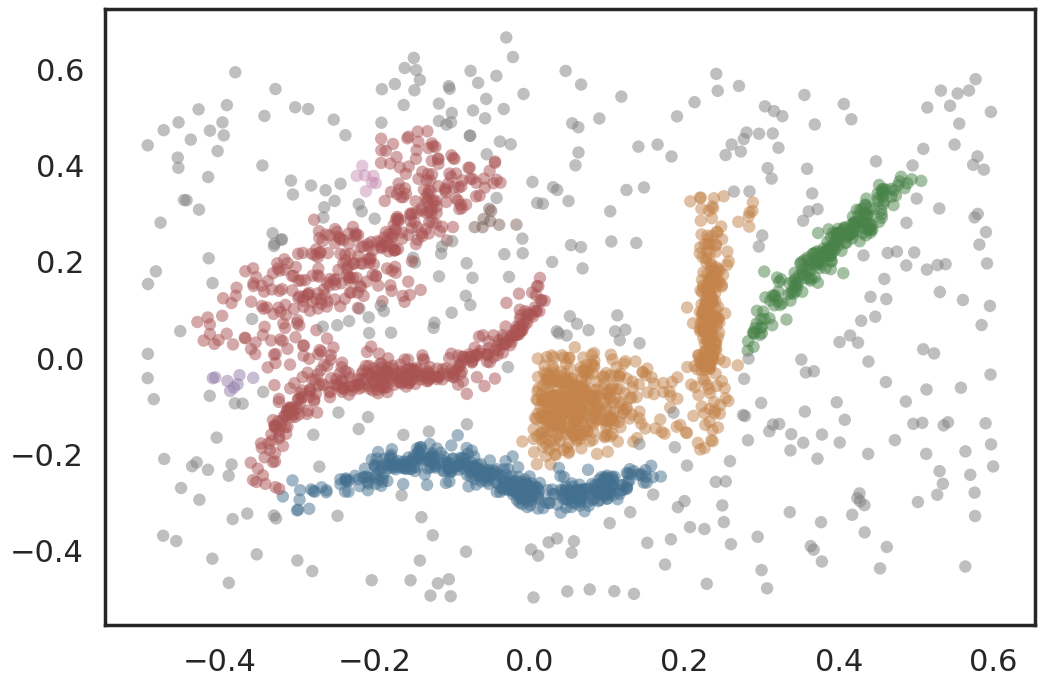

In [ ]:
plt.figure(figsize=(12,8))

palette = sns.color_palette()
cluster_colors = [sns.desaturate(palette[col], 0.5)
                  if col >= 0 else (0.5, 0.5, 0.5) for col in
                  db_clusterer.labels_]
plt.scatter(test_data.T[0], test_data.T[1], c=cluster_colors, **plot_kwds)

In [ ]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=15, gen_min_span_tree=True)
clusterer.fit(test_data)

HDBSCAN(gen_min_span_tree=True, min_cluster_size=15)

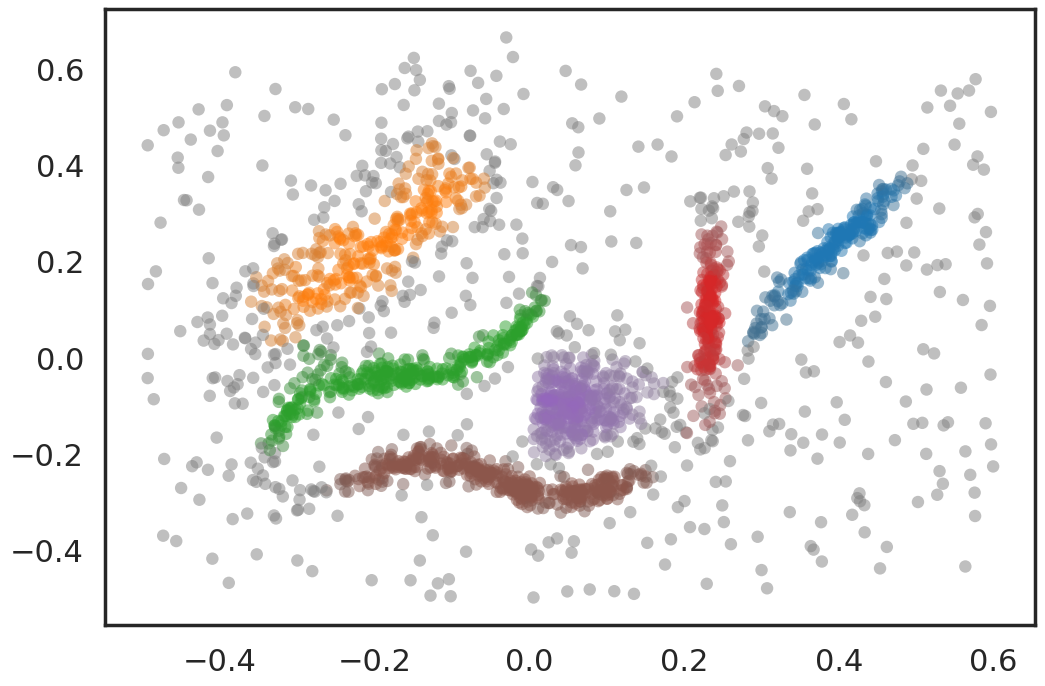

In [ ]:
plt.figure(figsize=(12,8))

palette = sns.color_palette()
cluster_colors = [sns.desaturate(palette[col], sat)
                  if col >= 0 else (0.5, 0.5, 0.5) for col, sat in
                  zip(clusterer.labels_, clusterer.probabilities_)]
plt.scatter(test_data.T[0], test_data.T[1], c=cluster_colors, **plot_kwds)